# Walking through Multi-head attention
* Let's see how the encoder process "Jack and Jill love Bill" through the attention module
* We'll convert each word into a numerical token
* Then associate an embedding vector with each token
* Add position encoding to the vector
* Compute (fake) Query, Key, and Value vectors
* Compute the attention filter
* Pass Value through the attention filter

In [ ]:
#All necessary import
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding


In [ ]:
#Define our sentence and place it in a corpus of inputs (only one sentence in the corpus)
sentence = "Jack and Jill love Bill"
corpus = [sentence]

#Vectorize the sentence (associate numerical tokens with words in the sentence)
vectorize_layer = TextVectorization(max_tokens=8, #upper limit on the vocab size
                                    standardize='lower_and_strip_punctuation',
                                    split='whitespace',
                                    output_mode='int',
                                    output_sequence_length=5) # length of each sentence (usually, sentences are padded to the same length)

#Build the vocabulary from words in the corpus
vectorize_layer.adapt(corpus)

#Print the size and the vocab
print(vectorize_layer.vocabulary_size())
print(vectorize_layer.get_vocabulary())

#Print the token vector
encoding = vectorize_layer(corpus)
print(f"'{sentence}' -> {encoding[0]}")

vocab_size = vectorize_layer.vocabulary_size()

#Set the embedding dimension (the number of features for each token)
embedding_dim = 4

embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
embedded_sentence = embedding(vectorize_layer(corpus))
print(embedded_sentence)


7
['', '[UNK]', 'love', 'jill', 'jack', 'bill', 'and']
'Jack and Jill love Bill' -> [4 6 3 2 5]
tf.Tensor(
[[[ 0.00230498 -0.01901056 -0.04074438  0.01774228]
  [-0.02094877  0.01378467  0.00867509  0.00156451]
  [ 0.04061485  0.04090739  0.00351113  0.02388551]
  [ 0.04627742  0.03171341 -0.0283169   0.03994578]
  [-0.01949575  0.041424   -0.03756412 -0.00340347]]], shape=(1, 5, 4), dtype=float32)


# Positional encoding

In [ ]:
#Define cos and sin functions
import math
def sine(pos,i,d):
  return math.sin(pos/(10000**((2*(i//2))/d)))

def cosine(pos,i,d):
  return math.cos(pos/(10000**((2*(i//2))/d)))



In [ ]:
#Calculate position vector values
import math
position_vector = np.zeros((5,4))
#Calculate position vectors
for pos in range(0,5):
  for i in range(0,4):
    if (i%2==0):
      position_vector[pos,i] = sine(pos,i,4)
    else:
      position_vector[pos,i] = cosine(pos,i,4)
position_vector

array([[ 0.        ,  1.        ,  0.        ,  1.        ],
       [ 0.84147098,  0.54030231,  0.00999983,  0.99995   ],
       [ 0.90929743, -0.41614684,  0.01999867,  0.99980001],
       [ 0.14112001, -0.9899925 ,  0.0299955 ,  0.99955003],
       [-0.7568025 , -0.65364362,  0.03998933,  0.99920011]])

In [ ]:
position_vector2 = tf.round(position_vector.copy() * 100)/100
position_vector2

<tf.Tensor: shape=(5, 4), dtype=float64, numpy=
array([[ 0.  ,  1.  ,  0.  ,  1.  ],
       [ 0.84,  0.54,  0.01,  1.  ],
       [ 0.91, -0.42,  0.02,  1.  ],
       [ 0.14, -0.99,  0.03,  1.  ],
       [-0.76, -0.65,  0.04,  1.  ]])>

# Add input embedding and position encoding


In [ ]:
input_embedding = embedded_sentence + position_vector
input_embedding

<tf.Tensor: shape=(1, 5, 4), dtype=float32, numpy=
array([[[ 0.00230498,  0.98098946, -0.04074438,  1.0177423 ],
        [ 0.8205222 ,  0.5540869 ,  0.01867492,  1.0015146 ],
        [ 0.94991225, -0.37523946,  0.0235098 ,  1.0236856 ],
        [ 0.18739742, -0.9582791 ,  0.0016786 ,  1.0394958 ],
        [-0.7762982 , -0.61221963,  0.00242521,  0.9957966 ]]],
      dtype=float32)>

# Query, Key, Value
* Query, Key, Value require weights
* These are built through training
* We'll just create a random set of weights to use for our example

In [ ]:
query_weights = np.random.rand(4,4)
key_weights = np.random.rand(4,4)
value_weights = np.random.rand(4,4)

In [ ]:
query = np.dot(input_embedding[0], query_weights)
key = np.dot(input_embedding[0], key_weights)
value = np.dot(input_embedding[0], value_weights)
print(query)
print(key)
print(value)

[[ 0.20242663  0.81975532  0.97230639  0.42956342]
 [ 0.89156077  1.45276739  1.24647411  0.8796572 ]
 [ 0.87101167  1.53858017  1.03694059  0.81095029]
 [ 0.08214942  0.94074992  0.50140775  0.247038  ]
 [-0.75251255  0.19474904  0.13557866 -0.2859598 ]]
[[1.60321263 1.11856555 1.52188654 1.2624788 ]
 [1.92813022 1.13728191 1.68307772 1.33649857]
 [1.42240391 0.86237276 1.24226618 1.00911736]
 [0.49341857 0.53300125 0.55770874 0.56847741]
 [0.00800433 0.45522038 0.26024915 0.43139558]]
[[ 1.67530581  0.38015285  1.90636507  1.0609768 ]
 [ 1.35457778  1.00981691  2.16010859  1.31890267]
 [ 0.67131628  0.95528953  1.3945307   1.15007659]
 [ 0.2260137   0.20626037  0.23182777  0.65040565]
 [ 0.42874373 -0.54264661 -0.24656867  0.25717012]]


# Attention filter

In [ ]:
query.shape, key.shape, value.shape

((5, 4), (5, 4), (5, 4))

In [ ]:
np.dot(query,key.T)/np.sqrt(4)


array([[ 1.63176886e+00,  1.76658797e+00,  1.31810517e+00,
         6.61636272e-01,  4.06571648e-01],
       [ 3.03095889e+00,  3.32241237e+00,  2.47855826e+00,
         1.20473711e+00,  6.86169863e-01],
       [ 2.85966658e+00,  3.12915441e+00,  2.33613013e+00,
         1.14457812e+00,  6.63534097e-01],
       [ 1.12947969e+00,  1.20118339e+00,  9.00149487e-01,
         4.81014966e-01,  3.32984063e-01],
       [-5.71640441e-01, -6.91726523e-01, -5.11286361e-01,
        -1.77225229e-01, -2.72359222e-03]])

In [ ]:

def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)
    return np.exp(x) / np.sum(np.exp(x), axis=1, keepdims=True)

attention_filter = softmax(np.dot(query,key.T)/np.sqrt(4))
print(attention_filter)

[[0.28186267 0.32254384 0.2059753  0.10683519 0.082783  ]
 [0.31537524 0.42208918 0.1815194  0.05078197 0.03023421]
 [0.31319531 0.41006465 0.18554372 0.05635881 0.0348375 ]
 [0.26020273 0.27954542 0.20687834 0.13604645 0.11732706]
 [0.16131827 0.14306416 0.1713543  0.2393183  0.28494498]]


# Compute value
* Dot product of the attention filter and V

In [ ]:
attention_filter.shape, value.shape

((5, 5), (5, 4))

In [ ]:
np.dot(value.T,attention_filter).T

array([[ 1.23763314,  0.69094505,  1.67588457,  1.28592116],
       [ 1.51191422,  0.92060509,  2.12802378,  1.58912158],
       [ 0.8357367 ,  0.38853741,  1.04922169,  0.84995297],
       [ 0.41895891,  0.0439289 ,  0.36448648,  0.39517397],
       [ 0.35171431, -0.03514339,  0.22864694,  0.31736214]])

In [ ]:
np.dot(query,key.T)
mask=np.zeros((5,5))
upper_indices = np.triu_indices(mask.shape[0], 1)

mask[upper_indices]=-np.inf
mask

array([[  0., -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.]])

# Masked Attention
* The masked attention unit in the decoder pays attention only to prior tokens, not to future ones
* In essence, the transformer is not paying attention to later tokens, only previous ones
* Future values are set to -inf by the following process

In [ ]:
mask=np.zeros((5,5))
upper_indices = np.triu_indices(mask.shape[0], 1)

mask[upper_indices]=-np.inf
mask

array([[  0., -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.]])

In [ ]:
np.dot(query,key.T)/np.sqrt(4) + mask

array([[ 1.63176886e+00,            -inf,            -inf,
                   -inf,            -inf],
       [ 3.03095889e+00,  3.32241237e+00,            -inf,
                   -inf,            -inf],
       [ 2.85966658e+00,  3.12915441e+00,  2.33613013e+00,
                   -inf,            -inf],
       [ 1.12947969e+00,  1.20118339e+00,  9.00149487e-01,
         4.81014966e-01,            -inf],
       [-5.71640441e-01, -6.91726523e-01, -5.11286361e-01,
        -1.77225229e-01, -2.72359222e-03]])

In [ ]:
m_attention_filter = softmax(np.dot(query,key.T)/np.sqrt(4) + mask)
m_attention_filter

array([[1.        , 0.        , 0.        , 0.        , 0.        ],
       [0.42764807, 0.57235193, 0.        , 0.        , 0.        ],
       [0.34462373, 0.45121367, 0.2041626 , 0.        , 0.        ],
       [0.29478952, 0.31670328, 0.23437712, 0.15413008, 0.        ],
       [0.16131827, 0.14306416, 0.1713543 , 0.2393183 , 0.28494498]])

In [ ]:
np.dot(value.T,m_attention_filter)

array([[ 2.62173056,  1.21111943,  0.26349719,  0.13744173,  0.12216837],
       [ 1.11447913,  0.99670042,  0.15039228, -0.09807434, -0.15462442],
       [ 3.33928407,  1.90371912,  0.29679554, -0.02327676, -0.0702585 ],
       [ 2.25456568,  1.5165842 ,  0.43131003,  0.16179259,  0.07327933]])

# Position encoding
* Each position corresponds to a vector of the same dimension as the embedding
* Since the value at each position is a function of the index in the embedding vector, think of each embedding dimension as representing a sine (or cosine) wave at a different amplitude
* Sine and Cosine functions are wave functions and can be plotted at different amplitudes as below


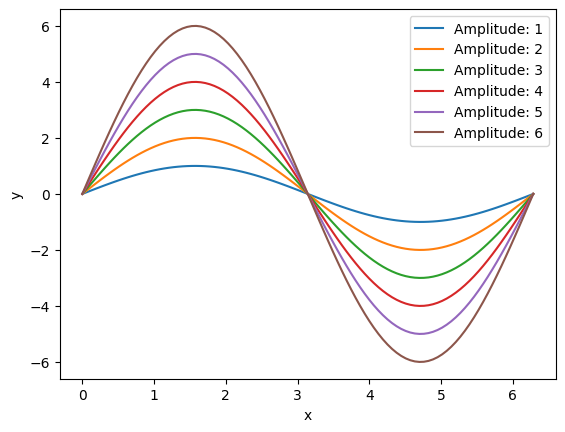

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis values
x = np.linspace(0, 2*np.pi, 100)

# Different amplitudes for sine waves
amplitudes = [1, 2, 3, 4, 5, 6]

# Plot each sine wave with different amplitudes
for amp in amplitudes:
    y = amp * np.sin(x)
    plt.plot(x, y, label=f"Amplitude: {amp}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

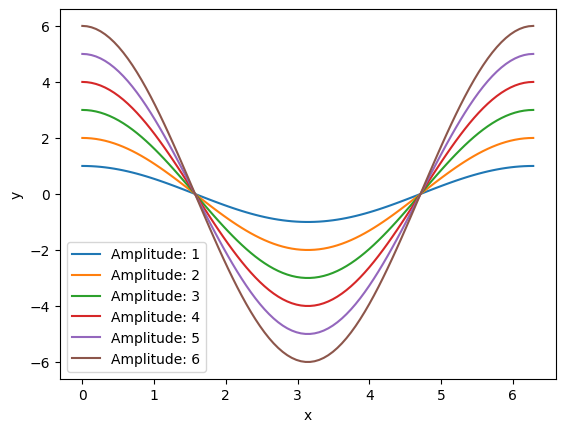

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define x-axis values
x = np.linspace(0, 2*np.pi, 100)

# Different amplitudes for sine waves
amplitudes = [1, 2, 3, 4, 5, 6]

# Plot each sine wave with different amplitudes
for amp in amplitudes:
    y = amp * np.cos(x)
    plt.plot(x, y, label=f"Amplitude: {amp}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

* Though, in position encoding, the waves are all normalized to between -1 and 1, the amplitude is represented by the scaling factor (the value being multiplied by pos
* Let's look at this factor

In [ ]:
#Define cos and sin functions
import math
def scaling(pos,i,d):
  scaling_factor = 1/(10000**((2*(i//2))/d))
  print(pos, i, scaling_factor, math.sin(pos*scaling_factor))



In [ ]:
scaling(1,0,4)

1 0 1.0 0.8414709848078965


In [ ]:
scaling(1,1,4)

1 1 1.0 0.8414709848078965


In [ ]:
scaling(1,2,4)

1 2 0.01 0.009999833334166664


In [ ]:
scaling(1,3,4)

1 3 0.01 0.009999833334166664


* For lower dimensions (low values of i) the scaling factor is larger, thus the value varies a lot as the value of pos (the position of the token in the sequence) changes
* For higher dimensions (high values of i) the scaling factor is smaller, thus the value is reasonably stable as pos changes
* We can see this in the following example

In [ ]:
#Calculate position vector values
import math
position_vector = np.zeros((8,9))
#Calculate position vectors
for pos in range(0,8):
  for i in range(0,9):
    if (i%2==0):
      position_vector[pos,i] = sine(pos,i,9)
    else:
      position_vector[pos,i] = cosine(pos,i,9)
tf.round(position_vector.copy() * 100)/100

<tf.Tensor: shape=(8, 9), dtype=float64, numpy=
array([[ 0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.84,  0.54,  0.13,  0.99,  0.02,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.91, -0.42,  0.26,  0.97,  0.03,  1.  ,  0.  ,  1.  ,  0.  ],
       [ 0.14, -0.99,  0.38,  0.93,  0.05,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.76, -0.65,  0.49,  0.87,  0.07,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.96,  0.28,  0.6 ,  0.8 ,  0.08,  1.  ,  0.01,  1.  ,  0.  ],
       [-0.28,  0.96,  0.7 ,  0.71,  0.1 ,  0.99,  0.01,  1.  ,  0.  ],
       [ 0.66,  0.75,  0.79,  0.62,  0.12,  0.99,  0.02,  1.  ,  0.  ]])>

* Another way of looking at this is by considering the frequency of the waves
** when i is small, the freqency of the wave is low and the wavelength is large. So small changes in pos result in big changes in sine value
** when i is large, the frequency is high and the wave length is small. So, small changes in pos result in small changes in sine value

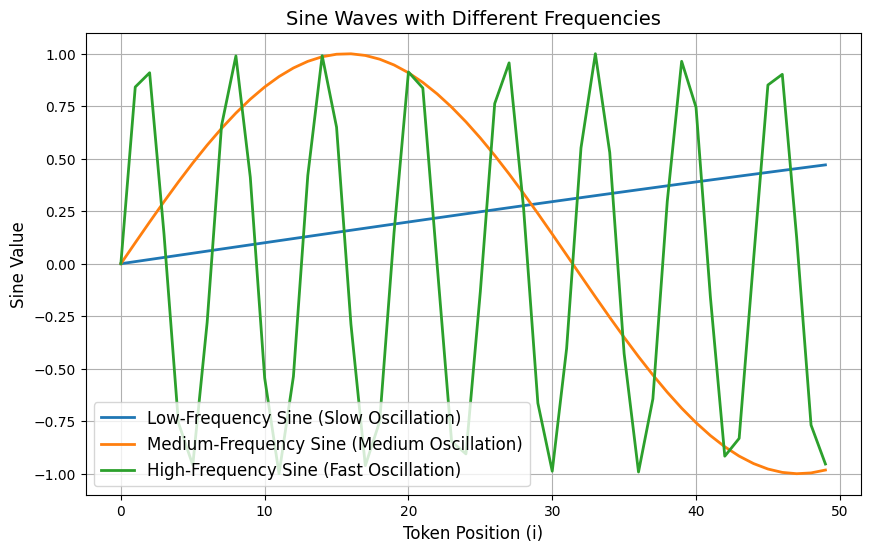

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate positions
positions = np.arange(0, 50, 1)  # 50 positions

# Define low-frequency and high-frequency scaling factors
low_freq_factor = 100  # For slow oscillation
med_freq_factor = 10  # For medium oscillation
high_freq_factor = 1   # For fast oscillation

# Compute sine values
low_freq_sine = np.sin(positions / low_freq_factor)
med_freq_sine = np.sin(positions / med_freq_factor)
high_freq_sine = np.sin(positions / high_freq_factor)

# Plot the sine waves
plt.figure(figsize=(10, 6))

# Low frequency
plt.plot(positions, low_freq_sine, label="Low-Frequency Sine (Slow Oscillation)", linewidth=2)

# Med frequency
plt.plot(positions, med_freq_sine, label="Medium-Frequency Sine (Medium Oscillation)", linewidth=2)

# High frequency
plt.plot(positions, high_freq_sine, label="High-Frequency Sine (Fast Oscillation)", linewidth=2)

# Formatting the plot
plt.title("Sine Waves with Different Frequencies", fontsize=14)
plt.xlabel("Token Position (i)", fontsize=12)
plt.ylabel("Sine Value", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# Intuition (the why)
* the slow oscillating waves (lower i) can capture long term position information (e.g., the subject usually comes early in the sentence)
* the fast oscillating waves (higher i) can capture short term relationships (e.g., "candle light")


# Why sine and cosine
* The authors of the paper say
* *We chose this function because we hypothesized it would allow the model to easily learn to attend by relative positions, since for any fixed offset k, PEpos+k can be represented as a linear function of PEpos.*
* If you're interested in figuring this out a good explanation and proof is at https://blog.timodenk.com/linear-relationships-in-the-transformers-positional-encoding/